# V2-03 — Where does novelty arise? (origins of novelty)

**Task V2-S06.** Exploratory cartography layer answering *where novelty comes from* along
three axes the current data supports:

1. **Sector × novelty** — is novelty from the tech/industry sector? (`institutions.type == 'company'`)
2. **Geography × novelty** — does novelty cluster by country? (`country_code`)
3. **Topic recombination** — recombinant novelty: papers whose references span ≥ 2 distinct topics.

Logic lives in `scifield.cartography.origins` (pure, I/O-free). This notebook only loads the
builder outputs (`V2/data/origins/*.parquet`, produced by `V2/scripts/build_origins.py`) and draws.

---
### ⚠️ Coverage caveats — read before interpreting any number
- **Panel-conditional.** This is the **10-journal surgical / orthopaedic corpus** (1995–2025),
  *not all of science*. "Company novelty" means company-affiliated **within this corpus**.
- **Institution-type blanks.** ~35% of institutions have a blank `type` and ~44% a blank
  `country_code`. Blanks are **dropped, never imputed** — every per-type / per-country table is
  conditioned on *resolved* affiliation metadata.
- **Any-author-affiliation rule.** A paper is tagged with **every** distinct sector / country among
  its author institutions, so a multi-sector paper is counted once per sector → per-row paper counts
  **sum above** the distinct paper total. This is the "novelty *present in* sector X" framing.
- **Recombination is a lower bound.** Only references resolving to a corpus topic count
  (`ref_openalex_id → archetypes.openalex_id → topic_id`); out-of-corpus references are invisible.
- **DEFERRED — funding origin & citation intents.** OpenAlex `grants` are now *parsed*
  (`parse_openalex_work`) but **not persisted** (a schema change + targeted re-harvest is required;
  `from_pylist` with the fixed schema silently drops the key). Semantic Scholar citation intents are
  empty (`citation_intents.parquet`, needs `SEMANTIC_SCHOLAR_API_KEY` + a re-run). Both are out of
  scope for this **$0** session — see the closing *Funding-origin: DEFERRED* note.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "V2" / "data" / "origins").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
ORIGINS = REPO_ROOT / "V2" / "data" / "origins"

sector = pd.read_parquet(ORIGINS / "sector_novelty.parquet")
geo = pd.read_parquet(ORIGINS / "geo_novelty.parquet")
recomb = pd.read_parquet(ORIGINS / "recombination.parquet")
recomb_topic = pd.read_parquet(ORIGINS / "recombination_by_topic.parquet")

print("sector rows:", len(sector), "| geo rows:", len(geo))
print("recombination papers:", len(recomb), "| topics:", len(recomb_topic))
sector.head()

sector rows: 9 | geo rows: 164
recombination papers: 81581 | topics: 149


,type,n_papers,sem_nov_mean_mean,sem_nov_mean_median,sem_nov_mean_std,sem_nov_mean_n,sem_nov_min_mean,sem_nov_min_median,sem_nov_min_std,sem_nov_min_n,cd5_mean,cd5_median,cd5_std,cd5_n,cd10_mean,cd10_median,cd10_std,cd10_n
0,archive,249,0.416406,0.405486,0.096643,244,0.156095,0.141072,0.068533,244,-0.354185,-0.500000,0.544186,241,-0.317783,-0.429882,0.520646,242
1,company,5091,0.410664,0.397893,0.087481,5055,0.156745,0.143916,0.071735,5055,-0.394567,-0.500000,0.494034,4882,-0.354357,-0.454545,0.470686,4903
2,education,46284,0.413667,0.401230,0.091615,45302,0.155414,0.141257,0.073241,45302,-0.396761,-0.500000,0.482228,44844,-0.355537,-0.446154,0.461768,45073
3,facility,4557,0.414072,0.404423,0.088488,4490,0.151995,0.139345,0.069085,4490,-0.405227,-0.500000,0.465029,4413,-0.363470,-0.448276,0.450643,4426
4,funder,7688,0.405100,0.394815,0.086522,7575,0.146270,0.133189,0.067486,7575,-0.419762,-0.511111,0.459407,7489,-0.384677,-0.476636,0.443729,7509


## 1. Sector × novelty — is novelty from the tech/industry sector?

`type == 'company'` is the tech/industry proxy. We plot mean semantic novelty (`sem_nov_mean`) and
mean disruption (`cd5`) per institution type, with the company bar highlighted.

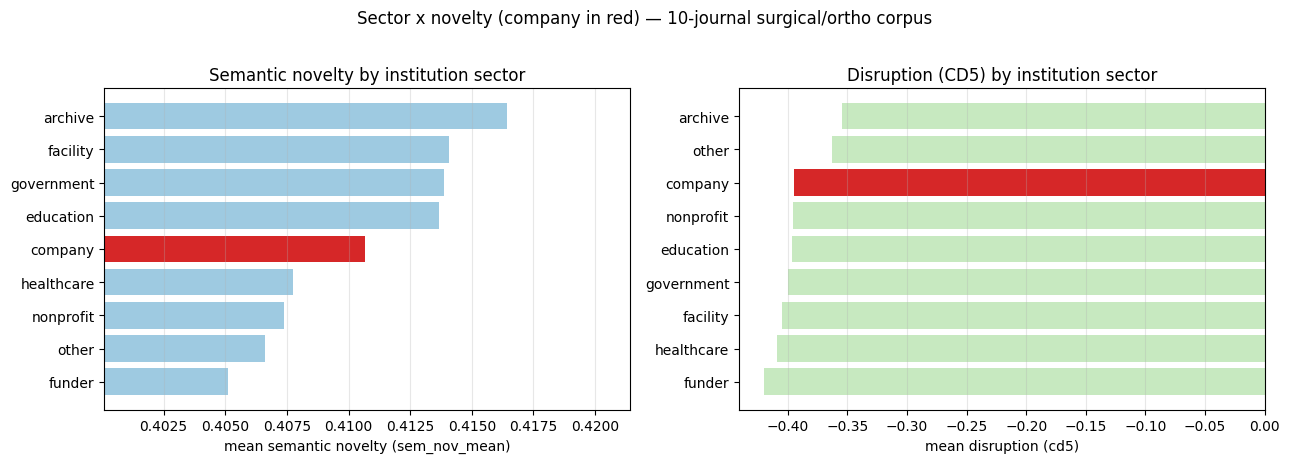

In [2]:
s = sector.sort_values("sem_nov_mean_mean", ascending=False).reset_index(drop=True)
colors = ["#d62728" if t == "company" else "#9ecae1" for t in s["type"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(s["type"], s["sem_nov_mean_mean"], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel("mean semantic novelty (sem_nov_mean)")
axes[0].set_title("Semantic novelty by institution sector")
axes[0].set_xlim(s["sem_nov_mean_mean"].min() - 0.005, s["sem_nov_mean_mean"].max() + 0.005)

s2 = sector.sort_values("cd5_mean", ascending=False).reset_index(drop=True)
colors2 = ["#d62728" if t == "company" else "#c7e9c0" for t in s2["type"]]
axes[1].barh(s2["type"], s2["cd5_mean"], color=colors2)
axes[1].invert_yaxis()
axes[1].set_xlabel("mean disruption (cd5)")
axes[1].set_title("Disruption (CD5) by institution sector")
for ax in axes:
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Sector x novelty (company in red) — 10-journal surgical/ortho corpus", y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# Company vs paper-weighted non-company contrast.
co = sector.set_index("type").loc["company"]
nc = sector[sector["type"] != "company"]
nc_sem = (nc["sem_nov_mean_mean"] * nc["n_papers"]).sum() / nc["n_papers"].sum()
nc_cd = (nc["cd5_mean"] * nc["cd5_n"]).sum() / nc["cd5_n"].sum()
print(f"COMPANY  sem_nov_mean = {co['sem_nov_mean_mean']:.4f}  (n={int(co['n_papers'])})")
print(f"NON-CO   sem_nov_mean = {nc_sem:.4f}  -> delta = {co['sem_nov_mean_mean'] - nc_sem:+.4f}")
print(f"COMPANY  cd5          = {co['cd5_mean']:.4f}")
print(f"NON-CO   cd5          = {nc_cd:.4f}  -> delta = {co['cd5_mean'] - nc_cd:+.4f}")

COMPANY  sem_nov_mean = 0.4107  (n=5091)
NON-CO   sem_nov_mean = 0.4103  -> delta = +0.0004
COMPANY  cd5          = -0.3946
NON-CO   cd5          = -0.4025  -> delta = +0.0079


**Reading.** Company-affiliated papers sit **mid-pack** on both axes — the company-vs-non-company
gap is tiny (within rounding of the corpus-wide mean). In this surgical/ortho corpus, **novelty is
NOT concentrated in the tech/industry sector**; sector is a *weak* origin signal. (Geography, below,
is the stronger axis.)

## 2. Geography × novelty

Per-country mean novelty, **blank country codes excluded**, low-n countries (< 30 papers) flagged.
We rank the well-sampled countries (the formal robustness check at both topic grains comes later in
the validation phase — this is the descriptive layer).

63 well-sampled countries (>= 30 papers); 101 low-n flagged


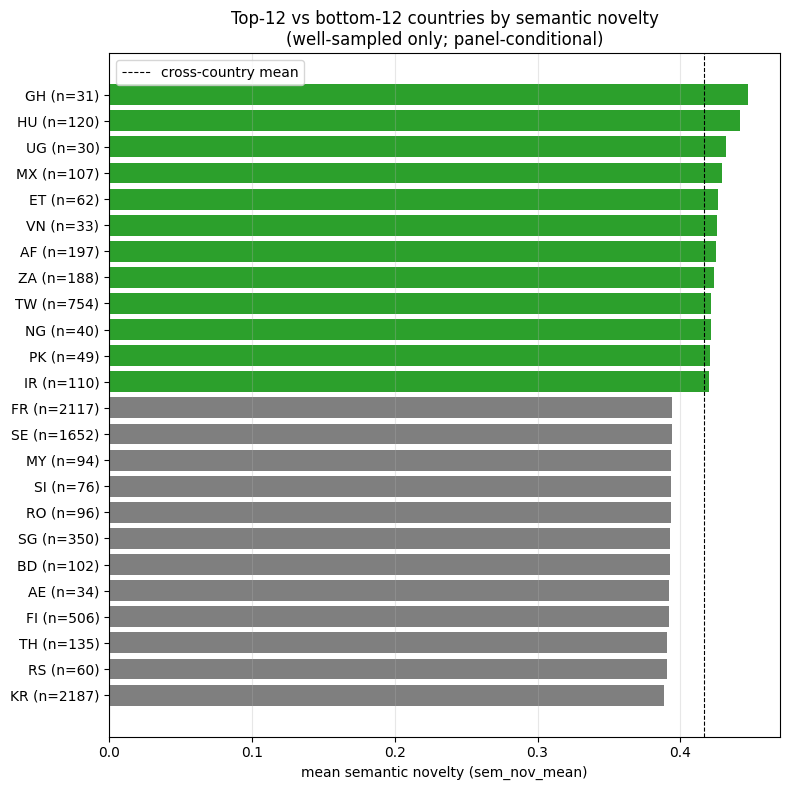

,country_code,n_papers,sem_nov_mean_mean,cd5_mean
0,GH,31,0.447467,-0.315000
1,HU,120,0.441571,-0.398534
2,UG,30,0.432140,-0.444678
3,MX,107,0.429219,-0.351631
4,ET,62,0.426134,-0.480852
5,VN,33,0.425851,-0.195909
6,AF,197,0.424832,-0.372384
7,ZA,188,0.423841,-0.365072
8,TW,754,0.421606,-0.446647
9,NG,40,0.421555,-0.388342


In [4]:
well = geo[~geo["low_n"]].sort_values("sem_nov_mean_mean", ascending=False).reset_index(drop=True)
print(f"{len(well)} well-sampled countries (>= 30 papers); {int(geo['low_n'].sum())} low-n flagged")

top = well.head(12)
bot = well.tail(12)
show = pd.concat([top, bot])
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
    show["country_code"] + " (n=" + show["n_papers"].astype(str) + ")",
    show["sem_nov_mean_mean"],
    color=["#2ca02c"] * len(top) + ["#7f7f7f"] * len(bot),
)
ax.invert_yaxis()
ax.axvline(geo["sem_nov_mean_mean"].mean(), color="k", ls="--", lw=0.8, label="cross-country mean")
ax.set_xlabel("mean semantic novelty (sem_nov_mean)")
ax.set_title(
    "Top-12 vs bottom-12 countries by semantic novelty\n(well-sampled only; panel-conditional)"
)
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
well.loc[:, ["country_code", "n_papers", "sem_nov_mean_mean", "cd5_mean"]].head(10)

**Reading.** Geography shows a **wider spread** than sector: lower- and middle-income / emerging
research countries (e.g. GH, HU, UG, MX, ET) rank highest on *semantic* novelty, while several
high-volume countries rank lower. This is **descriptive and panel-conditional** — it likely reflects
*topic mix* (which subfields a country publishes in within these 10 journals) rather than intrinsic
"more novel science", and small-n countries are excluded. **Geography is the more differentiated
origin axis** and the better candidate for the Gate-G6 robustness check, but that check (both topic
grains) is applied in the validation phase, not here.

## 3. Topic recombination (exploratory)

Recombinant novelty: a paper whose references span **≥ 2 distinct corpus topics** is recombining
literatures. Per paper we compute `n_distinct_topics` and a Shannon `topic_entropy`; per focal topic
we summarise the breadth + recombination rate.

papers with >=1 resolved ref: 81,581
recombination events (>=2 topics): 33,916 (41.6%)
mean distinct ref-topics/paper: 1.70


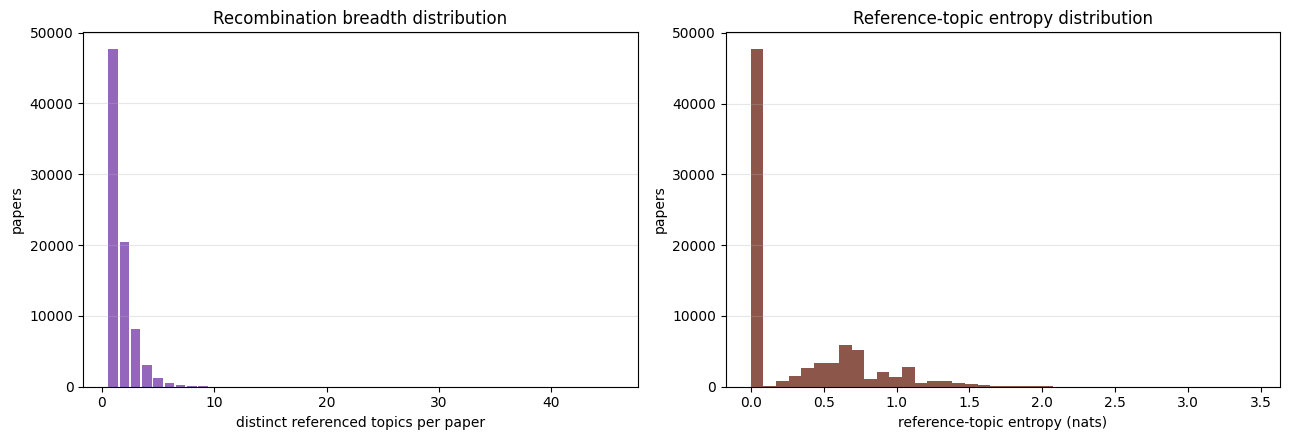

In [5]:
n_recomb = int(recomb["is_recombination"].sum())
print(f"papers with >=1 resolved ref: {len(recomb):,}")
print(f"recombination events (>=2 topics): {n_recomb:,} ({100*n_recomb/len(recomb):.1f}%)")
print(f"mean distinct ref-topics/paper: {recomb['n_distinct_topics'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(
    recomb["n_distinct_topics"],
    bins=range(1, recomb["n_distinct_topics"].max() + 2),
    color="#9467bd",
    align="left",
    rwidth=0.85,
)
axes[0].set_xlabel("distinct referenced topics per paper")
axes[0].set_ylabel("papers")
axes[0].set_title("Recombination breadth distribution")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(recomb["topic_entropy"], bins=40, color="#8c564b")
axes[1].set_xlabel("reference-topic entropy (nats)")
axes[1].set_ylabel("papers")
axes[1].set_title("Reference-topic entropy distribution")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

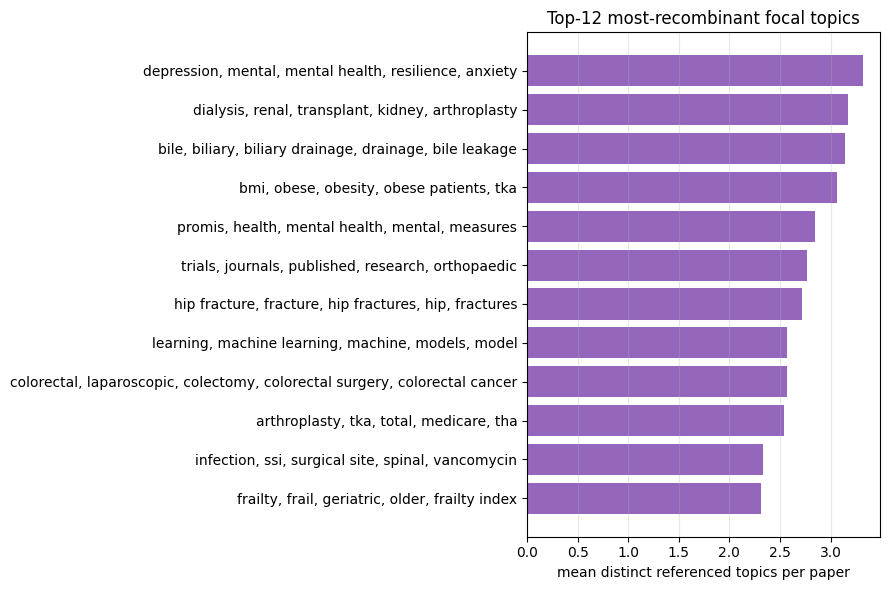

,topic_id,n_papers,mean_distinct_topics,recombination_rate,words
0,122,121,3.322314,0.867769,"depression, mental, mental health, resilience,..."
1,132,91,3.175824,0.901099,"dialysis, renal, transplant, kidney, arthroplasty"
2,130,91,3.142857,0.879121,"bile, biliary, biliary drainage, drainage, bil..."
3,45,460,3.063043,0.865217,"bmi, obese, obesity, obese patients, tka"
4,144,79,2.848101,0.810127,"promis, health, mental health, mental, measures"
5,51,348,2.767241,0.563218,"trials, journals, published, research, orthopa..."
6,137,77,2.714286,0.688312,"hip fracture, fracture, hip fractures, hip, fr..."
7,72,262,2.568702,0.744275,"learning, machine learning, machine, models, m..."
8,68,301,2.568106,0.747508,"colorectal, laparoscopic, colectomy, colorecta..."
9,7,1346,2.538633,0.698366,"arthroplasty, tka, total, medicare, tha"


In [6]:
# Most-recombinant focal topics with their top_words.
top = recomb_topic.sort_values("mean_distinct_topics", ascending=False).head(12).copy()
top["words"] = top["top_words"].apply(
    lambda w: ", ".join(list(w)[:5]) if w is not None and len(w) else ""
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["words"], top["mean_distinct_topics"], color="#9467bd")
ax.invert_yaxis()
ax.set_xlabel("mean distinct referenced topics per paper")
ax.set_title("Top-12 most-recombinant focal topics")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
top.loc[:, ["topic_id", "n_papers", "mean_distinct_topics", "recombination_rate", "words"]]

**Reading.** ~42% of papers with resolved references recombine ≥ 2 topics. The most-recombinant
focal topics are **interdisciplinary bridges** — mental-health / PROMIS outcomes, dialysis/transplant,
biliary drainage, obesity/BMI, machine-learning methods, evidence-synthesis/trials — i.e. topics that
*by construction* pull from many literatures. This is an exploratory layer (lower-bound, corpus-internal).

---
## Funding-origin: DEFERRED (coverage note)
**OpenAlex `grants` (funder / award ids)** are now extracted by
`scifield.corpus.openalex.parse_openalex_work` (additive `grants` key + `_parse_grants` helper), so a
funder × novelty analysis is *one re-harvest away*. It is **not run here** because:
1. The live `openalex_works.parquet` schema (`OPENALEX_WORKS_SCHEMA`) has **no `grants` column**, and
   `pyarrow.Table.from_pylist(rows, schema=...)` **silently drops** the extra key — so the on-disk store
   is unchanged and grants are *not* persisted. Wiring the column through `enrich_store.py` would change
   the schema and break the existing parquet / `test_corpus_enrich_store.py` round-trip **unless** the
   118k-row store is re-pulled to populate it.
2. A re-pull is a network re-harvest — **out of scope for this $0 session** (no DeepSeek, no paid APIs).

**To enable funding origin later:** (a) add a `grants` `list<struct>` field to `OPENALEX_WORKS_SCHEMA`
+ a `_sample_row` grants entry, (b) targeted OpenAlex re-pull (polite pool) to backfill, (c) join
`grants.funder → novelty`. **Citation-intent origin** is likewise deferred: `citation_intents.parquet`
is empty (needs `SEMANTIC_SCHOLAR_API_KEY` + a Semantic Scholar re-run).

**Acceptance (V2-S06):** sector + geography novelty tables are produced from current data (above);
funding + intent analyses are explicitly **deferred with this coverage note**.